<a href="https://colab.research.google.com/github/cristiangarbal10/ChallengeAllura-DataScience/blob/main/Challenge1_DataScience_Gardu%C3%B1oBaldazoCristian.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importación de datos



In [33]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


In [42]:
def explorar_tiendas_dataframes(tiendas_lista, nombres_tiendas):
    resultados = {}
    info = []
    for i, tienda in enumerate(tiendas_lista):
        info.append({
            'Tienda': nombres_tiendas[i],
            'Filas': tienda.shape[0],
            'Columnas': tienda.shape[1],
            'Duplicados': tienda.duplicated().sum(),
            'Total Nulos': tienda.isnull().sum().sum()
                    })
    resultados['info_general'] = pd.DataFrame(info)

    tipos = []
    for i, tienda in enumerate(tiendas_lista):
        for col in tienda.columns:
            tipos.append({
                'Tienda': nombres_tiendas[i],
                'Columna': col,
                'Tipo': tienda[col].dtype,
                'No Nulos': tienda[col].count(),
                'Nulos': tienda[col].isnull().sum()
                         })
    resultados['tipos_datos'] = pd.DataFrame(tipos)
    return resultados

resultados = explorar_tiendas_dataframes(tiendas, nombres)

print("\nESTRUCTURA DE LA INFORMACION DE LAS TIENDAS")
print("\nInformación General:\n")
print(resultados['info_general'])
print("\nInformación de las columnas:\n")
print(resultados['tipos_datos'])


ESTRUCTURA DE LA INFORMACION DE LAS TIENDAS

Información General:

     Tienda  Filas  Columnas  Duplicados  Total Nulos
0  Tienda 1   2359        12           0            0
1  Tienda 2   2359        12           0            0
2  Tienda 3   2359        12           0            0
3  Tienda 4   2358        12           0            0

Información de las columnas:

      Tienda                 Columna     Tipo  No Nulos  Nulos
0   Tienda 1                Producto   object      2359      0
1   Tienda 1  Categoría del Producto   object      2359      0
2   Tienda 1                  Precio  float64      2359      0
3   Tienda 1          Costo de envío  float64      2359      0
4   Tienda 1         Fecha de Compra   object      2359      0
5   Tienda 1                Vendedor   object      2359      0
6   Tienda 1         Lugar de Compra   object      2359      0
7   Tienda 1            Calificación    int64      2359      0
8   Tienda 1          Método de pago   object      2359      0
9

#1. Análisis de facturación



In [55]:
ingreso_tienda1 = tienda['Precio'].sum()
ingreso_tienda2 = tienda2['Precio'].sum()
ingreso_tienda3 = tienda3['Precio'].sum()
ingreso_tienda4 = tienda4['Precio'].sum()

print("INGRESO TOTAL POR TIENDA\n")
print(f"Tienda 1: ${ingreso_tienda1:,.2f}")
print(f"Tienda 2: ${ingreso_tienda2:,.2f}")
print(f"Tienda 3: ${ingreso_tienda3:,.2f}")
print(f"Tienda 4: ${ingreso_tienda4:,.2f}")
print(f"\nPromedio general: ${(ingreso_tienda1 + ingreso_tienda2 + ingreso_tienda3 + ingreso_tienda4)/4:,.2f}")
print(f"\nIngreso total combinado: ${ingreso_tienda1 + ingreso_tienda2 + ingreso_tienda3 + ingreso_tienda4:,.2f}")

INGRESO TOTAL POR TIENDA

Tienda 1: $1,150,880,400.00
Tienda 2: $1,116,343,500.00
Tienda 3: $1,098,019,600.00
Tienda 4: $1,038,375,700.00

Promedio general: $1,100,904,800.00

Ingreso total combinado: $4,403,619,200.00


# 2. Ventas por categoría

In [67]:
def ventas_por_categoria(df, nombre_tienda):
    print(f"\n{nombre_tienda}")
    print("-" * 40)
    categorias = df['Categoría del Producto'].value_counts()
    print(categorias)
    print(f"\nCategoría más vendida: {categorias.index[0]} ({categorias.values[0]} ventas)")
    total_ventas = len(df)
    print(f"\nTotal ventas de la tienda: {total_ventas}")

ventas_por_categoria(tienda, "Tienda 1")
ventas_por_categoria(tienda2, "Tienda 2")
ventas_por_categoria(tienda3, "Tienda 3")
ventas_por_categoria(tienda4, "Tienda 4")


Tienda 1
----------------------------------------
Categoría del Producto
Muebles                    465
Electrónicos               448
Juguetes                   324
Electrodomésticos          312
Deportes y diversión       284
Instrumentos musicales     182
Libros                     173
Artículos para el hogar    171
Name: count, dtype: int64

Categoría más vendida: Muebles (465 ventas)

Total ventas de la tienda: 2359

Tienda 2
----------------------------------------
Categoría del Producto
Muebles                    442
Electrónicos               422
Juguetes                   313
Electrodomésticos          305
Deportes y diversión       275
Instrumentos musicales     224
Libros                     197
Artículos para el hogar    181
Name: count, dtype: int64

Categoría más vendida: Muebles (442 ventas)

Total ventas de la tienda: 2359

Tienda 3
----------------------------------------
Categoría del Producto
Muebles                    499
Electrónicos               451
Juguetes    

# 3. Calificación promedio de la tienda


In [24]:
promedio1 = tienda['Calificación'].mean()
promedio2 = tienda2['Calificación'].mean()
promedio3 = tienda3['Calificación'].mean()
promedio4 = tienda4['Calificación'].mean()

print("CALIFICACION PROMEDIO DE CADA TIENDA\n")
print(f"Tienda 1: {promedio1:.2f}")
print(f"Tienda 2: {promedio2:.2f}")
print(f"Tienda 3: {promedio3:.2f}")
print(f"Tienda 4: {promedio4:.2f}")
print(f"\nPromedio general: {(promedio1 + promedio2 + promedio3 + promedio4)/4:.2f}")

CALIFICACION PROMEDIO DE CADA TIENDA

Tienda 1: 4.00
Tienda 2: 4.04
Tienda 3: 4.05
Tienda 4: 4.00

Promedio general: 4.02


# 4. Productos más y menos vendidos


PRODUCTOS MÁS VENDIDOS Y MENOS VENDIDOS POR TIENDA:



Tienda 1
----------------------------------------

TOP 5 MÁS VENDIDOS:
Producto
Microondas          60
TV LED UHD 4K       60
Armario             60
Secadora de ropa    58
Mesa de noche       56
Name: count, dtype: int64




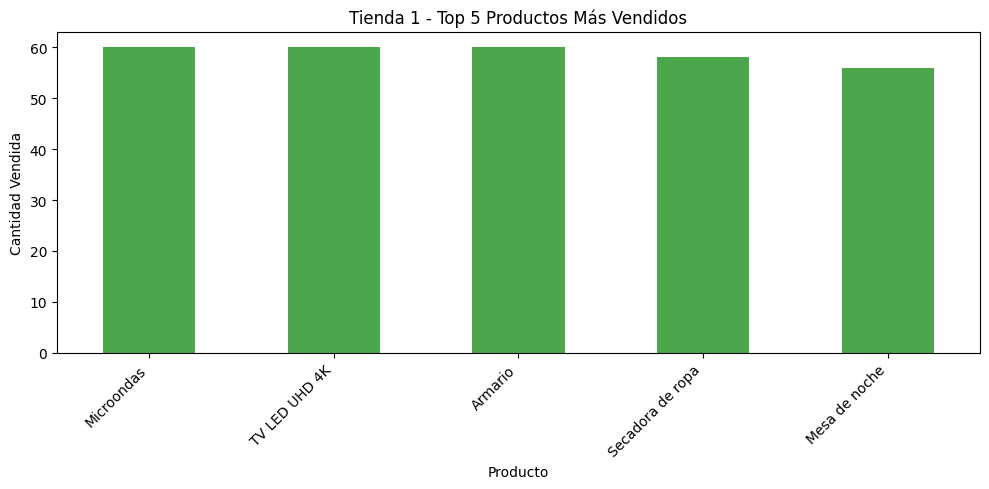


TOP 5 MENOS VENDIDOS:
Producto
Ciencia de datos con Python    39
Pandereta                      36
Olla de presión                35
Auriculares con micrófono      33
Celular ABXY                   33
Name: count, dtype: int64




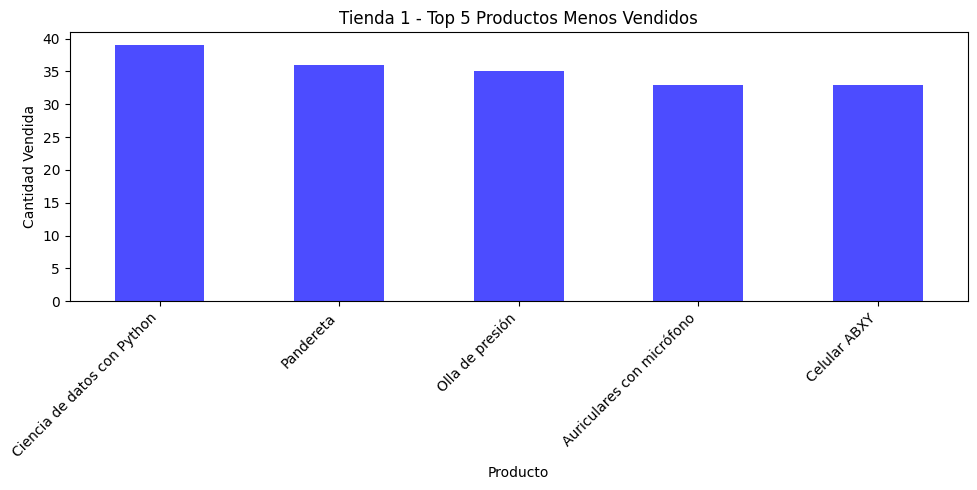



Tienda 2
----------------------------------------

TOP 5 MÁS VENDIDOS:
Producto
Iniciando en programación    65
Microondas                   62
Batería                      61
Guitarra acústica            58
Pandereta                    58
Name: count, dtype: int64




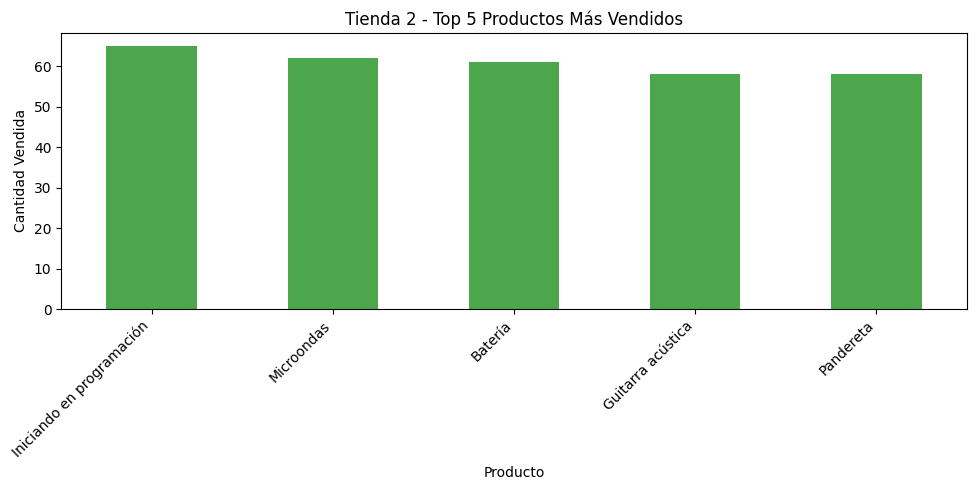


TOP 5 MENOS VENDIDOS:
Producto
Auriculares        37
Sillón             35
Mesa de comedor    34
Impresora          34
Juego de mesa      32
Name: count, dtype: int64




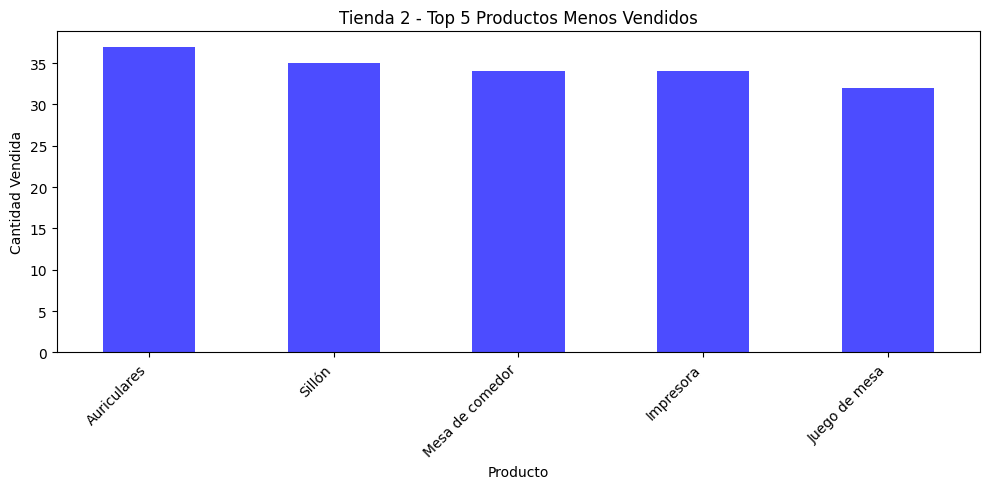



Tienda 3
----------------------------------------

TOP 5 MÁS VENDIDOS:
Producto
Kit de bancas      57
Mesa de comedor    56
Cama king          56
Set de ollas       55
Mesa de noche      55
Name: count, dtype: int64




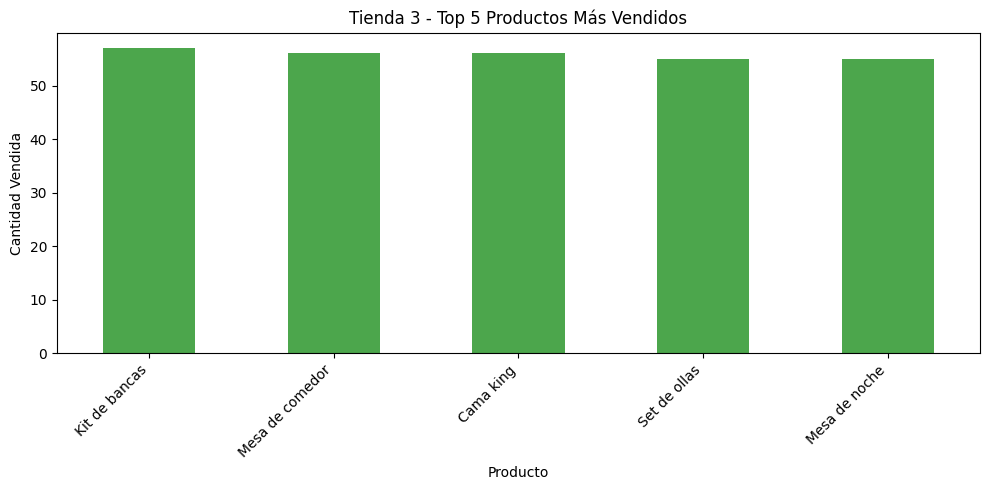


TOP 5 MENOS VENDIDOS:
Producto
Guitarra eléctrica         38
Set de vasos               36
Mochila                    36
Microondas                 36
Bloques de construcción    35
Name: count, dtype: int64




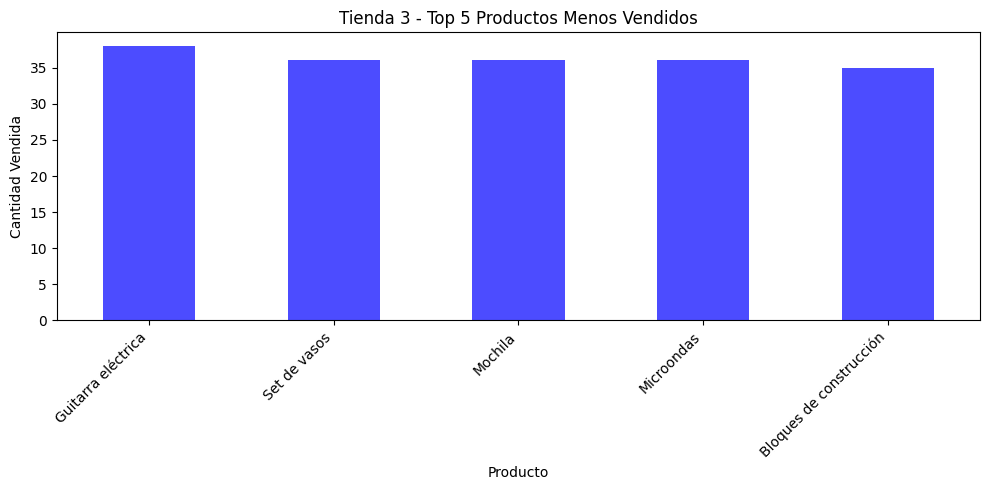



Tienda 4
----------------------------------------

TOP 5 MÁS VENDIDOS:
Producto
Cama box                     62
Cubertería                   59
Dashboards con Power BI      56
Cama king                    56
Carrito de control remoto    55
Name: count, dtype: int64




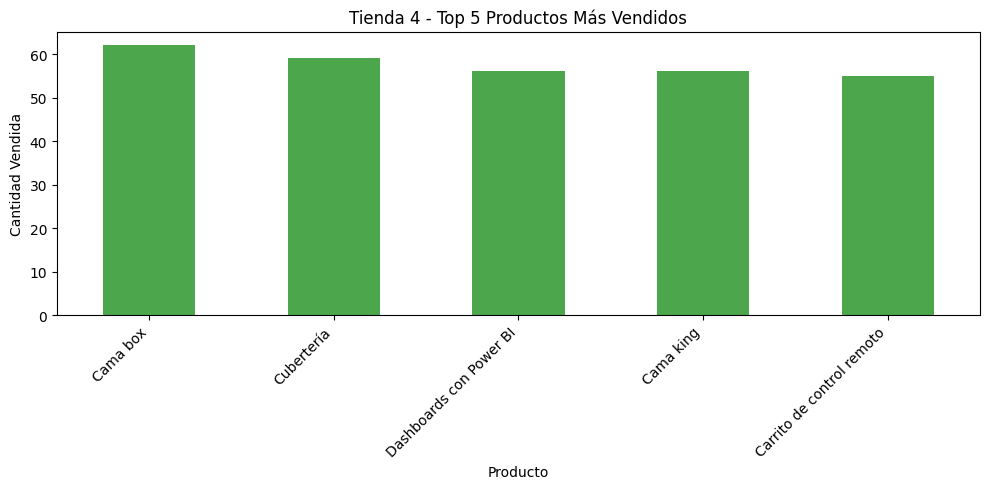


TOP 5 MENOS VENDIDOS:
Producto
Refrigerador                   38
Ciencia de datos con Python    38
Guitarra acústica              37
Armario                        34
Guitarra eléctrica             33
Name: count, dtype: int64




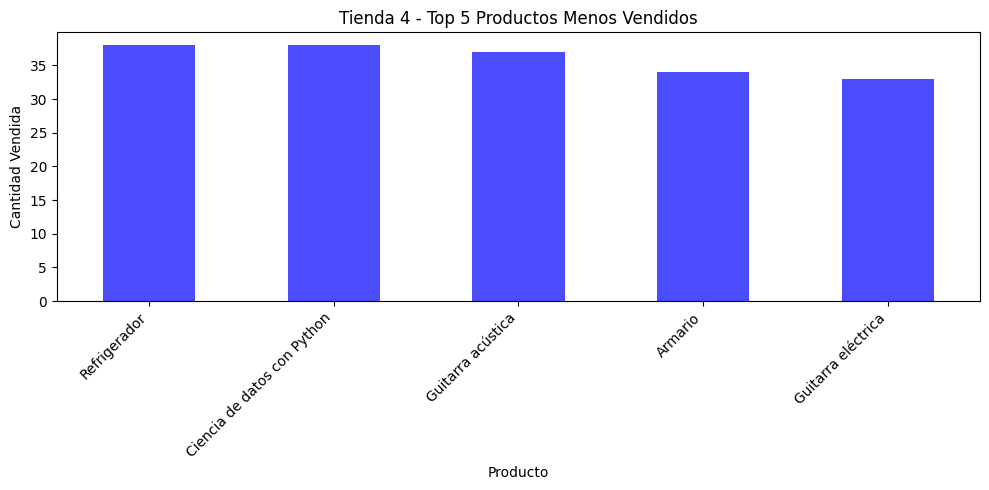

In [47]:
print(f"\nPRODUCTOS MÁS VENDIDOS Y MENOS VENDIDOS POR TIENDA:\n")

def analizar_productos(df, nombre_tienda):
    print(f"\n\n{nombre_tienda}")
    print(f"{'-'*40}")

    ventas = df['Producto'].value_counts()

    print(f"\nTOP 5 MÁS VENDIDOS:")
    print(ventas.head(5))
    print("\n")

    plt.figure(figsize=(10,5))
    ventas.head(5).plot(kind='bar', color='green', alpha=0.7)
    plt.title(f'{nombre_tienda} - Top 5 Productos Más Vendidos')
    plt.ylabel('Cantidad Vendida')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    print(f"\nTOP 5 MENOS VENDIDOS:")
    print(ventas.tail(5))
    print("\n")

    plt.figure(figsize=(10,5))
    ventas.tail(5).plot(kind='bar', color='blue', alpha=0.7)
    plt.title(f'{nombre_tienda} - Top 5 Productos Menos Vendidos')
    plt.ylabel('Cantidad Vendida')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

analizar_productos(tienda, "Tienda 1")
analizar_productos(tienda2, "Tienda 2")
analizar_productos(tienda3, "Tienda 3")
analizar_productos(tienda4, "Tienda 4")

# 5. Envío promedio por tienda

COSTO DE ENVÍO PROMEDIO DE CADA TIENDA
----------------------------------------
Tienda 1: $26,018.61
Tienda 2: $25,216.24
Tienda 3: $24,805.68
Tienda 4: $23,459.46

Promedio general de envio de las 4 tiendas: $24,875.00



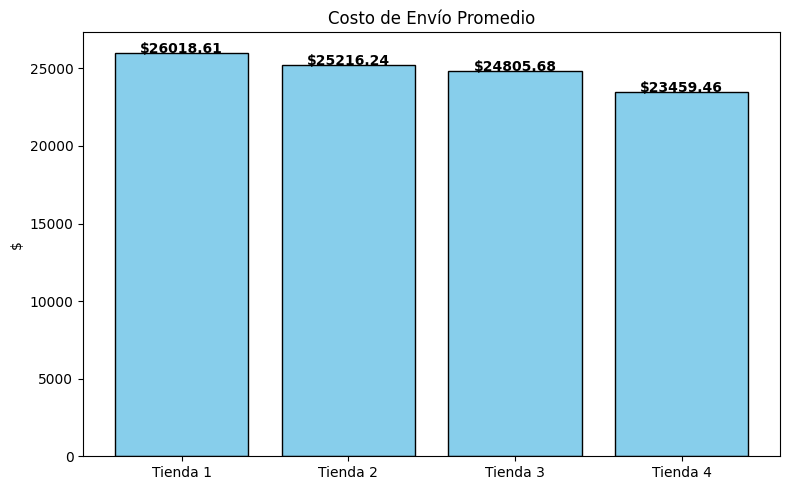

In [57]:
promedios = [
    tienda['Costo de envío'].mean(),
    tienda2['Costo de envío'].mean(),
    tienda3['Costo de envío'].mean(),
    tienda4['Costo de envío'].mean()
]

nombres = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']

# Mostrar tabla
print("COSTO DE ENVÍO PROMEDIO DE CADA TIENDA")
print("-" * 40)
for nombre, prom in zip(nombres, promedios):
    print(f"{nombre}: ${prom:,.2f}")

print(f"\nPromedio general de envio de las 4 tiendas: ${sum(promedios)/4:,.2f}\n")

plt.figure(figsize=(8, 5))
plt.bar(nombres, promedios, color='skyblue', edgecolor='black')
plt.title('Costo de Envío Promedio')
plt.ylabel('$')
for i, v in enumerate(promedios):
    plt.text(i, v + 0.5, f'${v:.2f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# 6. Informe del Analisis de las Tiendas

En base a los resultados que se obtuvieron del analisis de los datos que se nos proporcionaron sobre cada una de las tiendas y sus diferentes aspectos, podemos decir que la tienda 4 es la que debe de ser vendida por las siguientes razones:
* En el apartado de ingresos, no se acerca a la media de ingresos por tienda y tambien es la tienda que genera menos dinero.
* En el apartado de ventas por categoria, en las 4 tiendas su mayor categoria es de muebles, en esta categoria la tienda 4 es el lider en ventas pero al final se queda fuera por que no alcanza la media de ventas totales por tienda.
* En el apartado de popularidad entre los clientes, aunque las 4 tiendas no difieren por mucho en sus reseñas esta queda en ultimo lugar junto con la tienda 1 en cuestion de popularidad.
* En los top 5 de sus más y menos vendidos, aunque no es la ultima tienda en cuestion de mayores ventas de sus populares o de sus menos populares, esta a muy poca diferencia del ultimo lugar.
* En cuestion de envio por tienda, aunque opara el consumidor es beneficioso que la tienda 4 sea la más barata en envios para lo que vende y sus totales no es beneficioso a largo plazo.

En conclusion, la tienda 4 es la opción mas viable para vender; ya que no genera las suficientes ganancias a pesar de ser la tienda que lidera las ventas en la categoria de muebles (la categoria más vendida de entre las 4 tiendas) y tambien por su bajo coste en envios; que aunque para el consumidor es un aspecto bueno, es más perjudicial para poder generar ingresos.

##  7. Extra

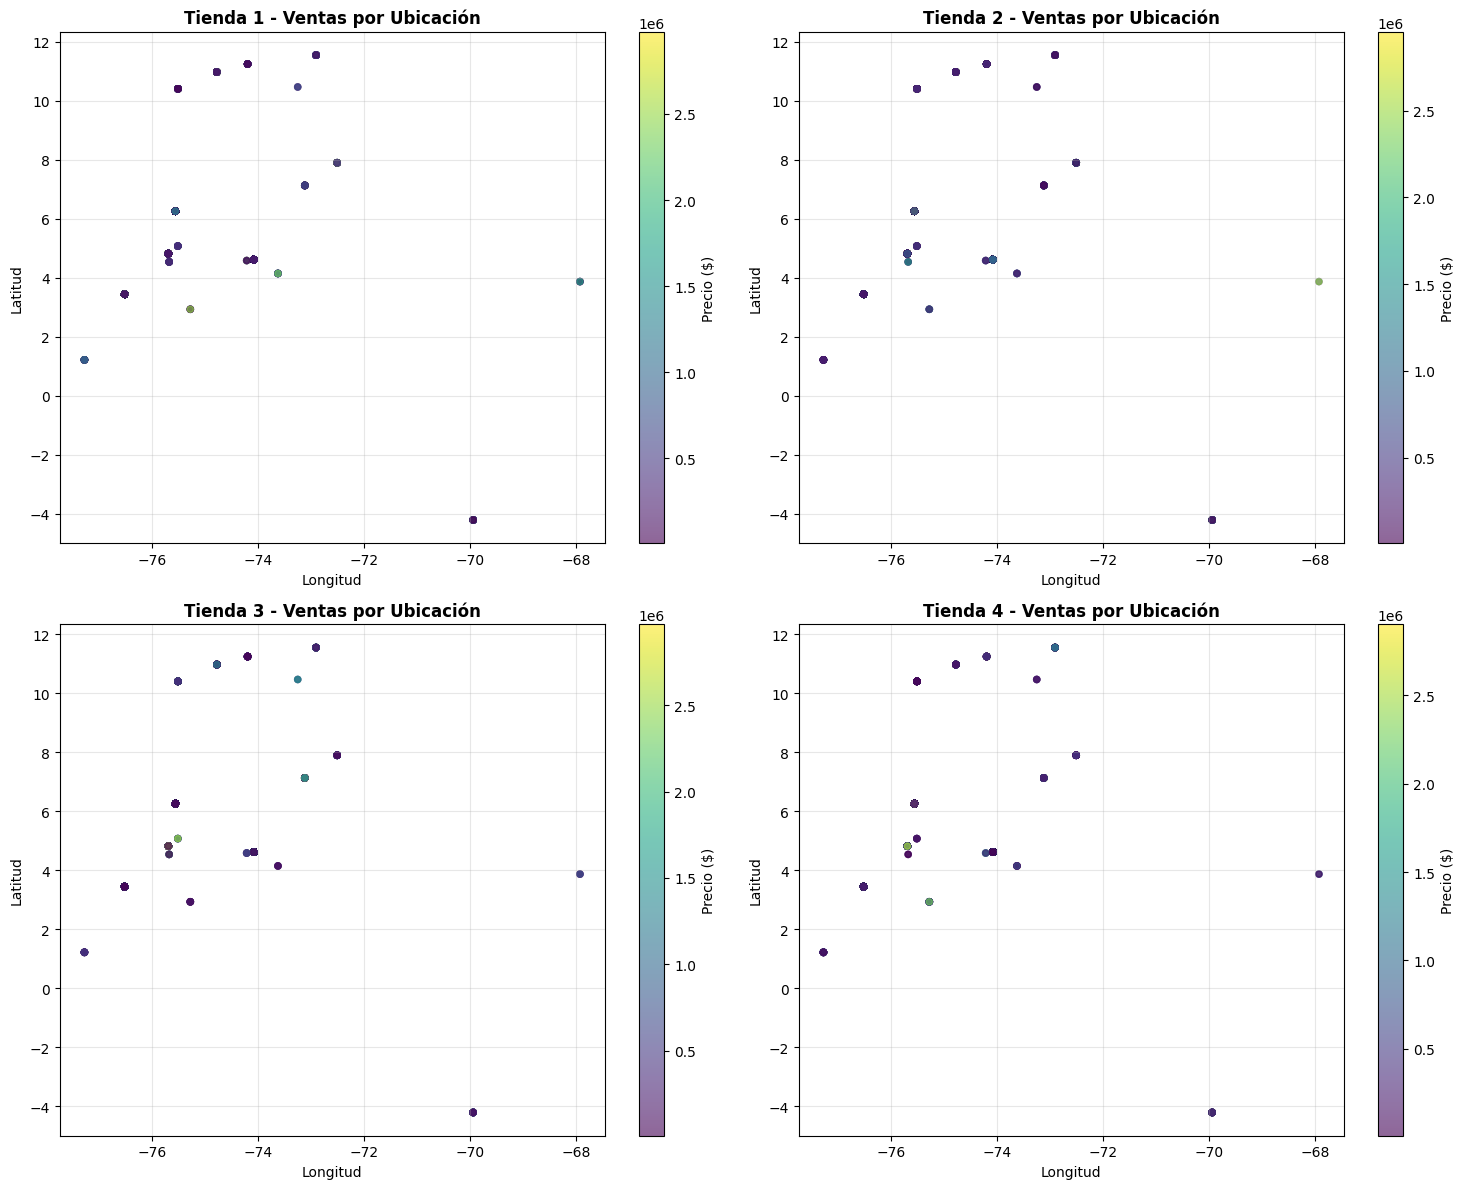


📊 ESTADÍSTICAS GEOGRÁFICAS BÁSICAS:

Tienda 1:
  Rango latitud: -4.2153 - 11.5444
  Rango longitud: -77.2811 - -67.9239
  Ubicaciones únicas: 19

Tienda 2:
  Rango latitud: -4.2153 - 11.5444
  Rango longitud: -77.2811 - -67.9239
  Ubicaciones únicas: 19

Tienda 3:
  Rango latitud: -4.2153 - 11.5444
  Rango longitud: -77.2811 - -67.9239
  Ubicaciones únicas: 19

Tienda 4:
  Rango latitud: -4.2153 - 11.5444
  Rango longitud: -77.2811 - -67.9239
  Ubicaciones únicas: 19


In [48]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

tiendas_lista = [tienda, tienda2, tienda3, tienda4]
nombres = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']

for i, (df, nombre) in enumerate(zip(tiendas_lista, nombres)):
    ax = axes[i]

    # Gráfico de dispersión básico
    scatter = ax.scatter(df['lon'], df['lat'], c=df['Precio'],
                        cmap='viridis', alpha=0.6, s=20)

    ax.set_title(f'{nombre} - Ventas por Ubicación', fontweight='bold')
    ax.set_xlabel('Longitud')
    ax.set_ylabel('Latitud')
    ax.grid(True, alpha=0.3)

    # Agregar colorbar
    plt.colorbar(scatter, ax=ax, label='Precio ($)')

plt.tight_layout()
plt.show()

# Mostrar estadísticas básicas por tienda
print("\n📊 ESTADÍSTICAS GEOGRÁFICAS BÁSICAS:")
for i, (df, nombre) in enumerate(zip(tiendas_lista, nombres)):
    print(f"\n{nombre}:")
    print(f"  Rango latitud: {df['lat'].min():.4f} - {df['lat'].max():.4f}")
    print(f"  Rango longitud: {df['lon'].min():.4f} - {df['lon'].max():.4f}")
    print(f"  Ubicaciones únicas: {df.groupby(['lat', 'lon']).ngroups}")